In [1]:
import sys, os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import logging
from datetime import datetime
from tqdm import tqdm
from pickle import dump, load
from functorch import make_functional, vmap, vjp, jvp, jacrev
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import PAIRWISE_KERNEL_FUNCTIONS, KERNEL_PARAMS

sys.path.append(os.getcwd())
logger = logging.getLogger(__name__)

def my_excepthook(excType, excValue, traceback):
    logger.error("Logging an uncaught exception",
                 exc_info=(excType, excValue, traceback))
    
logPath = './logs/'
if not os.path.exists(logPath):
    os.makedirs(logPath)
sys.excepthook = my_excepthook
fileName = str(datetime.now()).split('.')[0]
logging.basicConfig(
    level=logging.INFO,
#     level=logging.WARNING,
    format="%(asctime)s [%(name)s] [%(levelname)s] %(message)s",
    datefmt='%Y-%m-%d %H:%M:%S',
    handlers=[
        logging.FileHandler("{0}{1}.log".format(logPath, fileName)),
        logging.StreamHandler()
    ]
)
logging.getLogger('matplotlib').setLevel(logging.WARNING)

%load_ext autoreload
%autoreload 2

In [2]:
from ModelPrivacy import *

In [3]:
%matplotlib inline

In [4]:
def exp(server, attacker, n_train=100, valid=None):
    # Collect data and train the attacker
    attacker.collect_data(n_train, server)
    attacker.train()
    # Evaluate the attacker's test error
    return valid.eval(attacker.algorithm)

# Plot Ploy and KRR

In [1]:
# from ModelPrivacy._plot_cfg import *
from ModelPrivacy.utils import paste
import os, sys
import matplotlib.pyplot as plt
import pandas as pd
from pickle import load
import seaborn as sns
import numpy as np

In [2]:
defenses = ['None', 'IID', 'Const', 'Corr', 'KRR']

In [4]:
import scienceplots
plt.style.use(['science','no-latex'])
palette = sns.color_palette("tab10", len(defenses))

In [7]:
SMALL_SIZE = 12
MEDIUM_SIZE = 15
BIGGER_SIZE = 20
plt.rc('font',       size=15)  # controls default text sizes
plt.rc('axes',  titlesize=15)  # fontsize of the axes title
plt.rc('axes',  labelsize=15)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=15)  # fontsize of the tick labels
plt.rc('ytick', labelsize=15)  # fontsize of the tick labels
# plt.rc('legend', fontsize=10)  # legend fontsize
# plt.rc('figure', titlesize=12)  # fontsize of the figure title

# rc = {"font.family" : "Computer Modern", 
      # "mathtext.fontset" : "stix"}
# plt.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
# plt.rc('text', usetex=True)
# plt.rcParams.update(rc)
# plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

In [16]:
dataset = 'poly'
path=f'./saved_models/{dataset}/'
save_path = f'./plots/{dataset}/'
penalty='BC'

In [56]:
plt.rcParams.update(plt.rcParamsDefault)

In [6]:
palette = sns.color_palette("tab10", len(defenses))

<Figure size 216x288 with 0 Axes>

[(5e-05, 10)]

[Text(0, 0.0001, '$0$'),
 Text(0, 0.01, '$10^{-2}$'),
 Text(0, 0.1, '$10^{-1}$'),
 Text(0, 1.0, '1'),
 Text(0, 2.0, '2')]

Text(0.5, 0, 'Sample size $n$')

Text(0, 0.5, 'Privacy level $PL_n$')

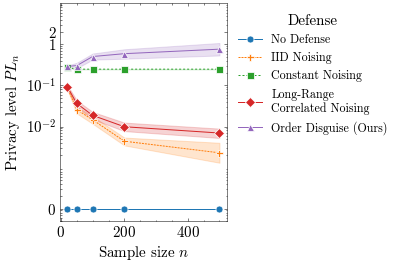

In [17]:
defenses = ['None', 'IID', 'Const', 'Corr', 'Poly' if dataset == 'poly' else 'KRR']
names = {'None': 'No Defense',
        'IID': 'IID Noising',
        'Const': 'Constant Noising',
        'Corr': 'Long-Range\nCorrelated Noising',
        'Poly': 'Order Disguise (Ours)',
         'KRR': 'Kernel Confusion (Ours)',
        # 'CorrSort': 'CorrSort',
         }
ns = [20, 50, 100, 200, 500]
long_df = pd.DataFrame(columns=['Defense', 'n', 'value'])
for n in ns:
    for d in defenses:
        tail = f'_{penalty}' if dataset == 'poly' else ''
        with open(path+f'n_{n}_{d}{tail}.pkl','rb') as f:
            metrics = load(f)
            err = pd.DataFrame({'Defense': names[d], 'n': n, 'value': metrics['err'].reshape(-1)})
            long_df = pd.concat([long_df, err], axis=0)

markers = ['o', 'P', 's', 'D', '^', 'X'][:len(defenses)]
line_types = ['', (2, 1),  (2, 2), '','', (2, 3), '', (2, 4)][:len(defenses)]
val = 1e-4
if dataset == 'poly':
    long_df.loc[long_df['Defense'] == 'No Defense', 'value'] = val
long_df = long_df.reset_index()

plt.figure(figsize=(3, 4))
g = sns.lineplot(data=long_df, x='n', y='value', hue='Defense', markers=markers, dashes=line_types, style='Defense', 
                 markersize=7, palette=palette)
plt.yscale('log')
# vmax = long_df['value'].max()
# print(vmax)
g.axes.set(ylim=(0.5*val, 10))
g.axes.set_yticks([val, 1e-2, 1e-1, 1, 2])
# g.axhline(val, ls='-', color='blue')
# g.axes.text(0.1, np.log(0.25), r"$a_n$")
g.axes.set_yticklabels([r'$0$',  r'$10^{-2}$', r'$10^{-1}$', '1', '2'])
plt.xlabel(r'Sample size $n$')
plt.ylabel(r'Privacy level $PL_n$')
plt.legend(bbox_to_anchor=(1, 1), title='Defense', fontsize=12)
# plt.tight_layout()
plt.savefig(save_path + f'{dataset}_n{tail}.pdf')
# plt.close()

In [46]:
# dataset='poly'
# defenses = ['None', 'IID', 'Const', 'Corr', 'Poly']

<Figure size 216x288 with 0 Axes>

[(5e-05, 10)]

[Text(0, 0.0001, '$0$'),
 Text(0, 0.01, '$10^{-2}$'),
 Text(0, 0.1, '$10^{-1}$'),
 Text(0, 1.0, '1'),
 Text(0, 2.0, '2')]

Text(0.5, 0, 'Utility loss $U_n$')

Text(0, 0.5, 'Privacy level $PL_n$')

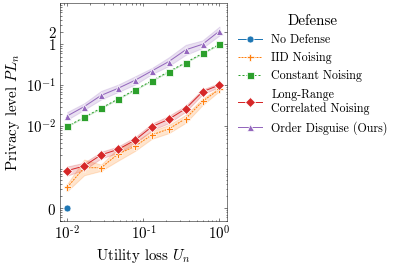

In [18]:
sigmas = np.logspace(-1, 0, 10)
long_df = pd.DataFrame(columns=['Defense', 'n', 'value'])
tail = f'_{penalty}' if dataset == 'poly' else ''
for sigma in sigmas:
    for d in defenses:
        with open(path+f'sigma_{sigma}_{d}{tail}.pkl','rb') as f:
            metrics = load(f)
            err = pd.DataFrame({'Defense': names[d], 'ul': sigma**2, 'value': metrics['err'].reshape(-1)})
            long_df = pd.concat([long_df, err], axis=0)

val = 1e-4
long_df.loc[long_df['Defense'] == 'No Defense', 'value'] = val if dataset == 'poly' else np.min(long_df.loc[long_df['Defense'] == 'No Defense', 'value'].to_numpy())
long_df.loc[long_df['Defense'] == 'No Defense', 'ul'] = 0.01
long_df = long_df.reset_index()
plt.figure(figsize=(3, 4))
g = sns.lineplot(data=long_df, x='ul', y='value', hue='Defense', markers=markers, markersize=7,
                 dashes=line_types, style='Defense', palette=palette)
plt.yscale('log')
plt.xscale('log')
# vmax = long_df['value'].max()
# print(vmax)
g.axes.set(ylim=(0.5*val, 10))
g.axes.set_yticks([val, 1e-2, 1e-1, 1, 2])
# g.axhline(val, ls='-', color='blue')
# g.axes.text(0.1, np.log(0.25), r"$a_n$")
g.axes.set_yticklabels([r'$0$',  r'$10^{-2}$', r'$10^{-1}$', '1', '2'])
plt.xlabel(r'Utility loss $U_n$')
plt.ylabel(r'Privacy level $PL_n$')

handles, labels = g.get_legend_handles_labels()
# handles[0].set_linestyle("")

plt.legend(handles, labels, bbox_to_anchor=(1, 1), title='Defense', fontsize=12)
# plt.tight_layout()
plt.savefig(save_path + f'{dataset}_ratio{tail}.pdf')
# plt.close()

In [100]:
handles, labels = g.get_legend_handles_labels()

handles[0].set_linestyle("")

# LASSO

In [77]:
kind = 7
df = pd.read_csv(f'./saved_models/lasso_sim_{kind}.csv', index_col=0)
df = df[df['attack'] != 'Ridge']

In [78]:
defenses = df['defense'].unique()
palette = sns.color_palette("tab10", len(defenses))
markers = ['o', 'P', 's', 'D', '^', 'X'][:len(defenses)]
line_types = ['', (2, 1),  (2, 2), '','', (2, 3), '', (2, 4)][:len(defenses)]
name_dic = {'No': 'No Defense', 'Const': 'Constant Noising', 'IID': 'IID Noising', 
            'Corr': 'Long-Range\nCorrelated Noising', 'LASSO': 'Misleading Variable\nProjection (Ours)'}

df['defense'] = df['defense'].map(lambda x: name_dic[x] if x in name_dic.keys() else x)
df.loc[df['defense']=='No Defense', 'un'] = -0.01

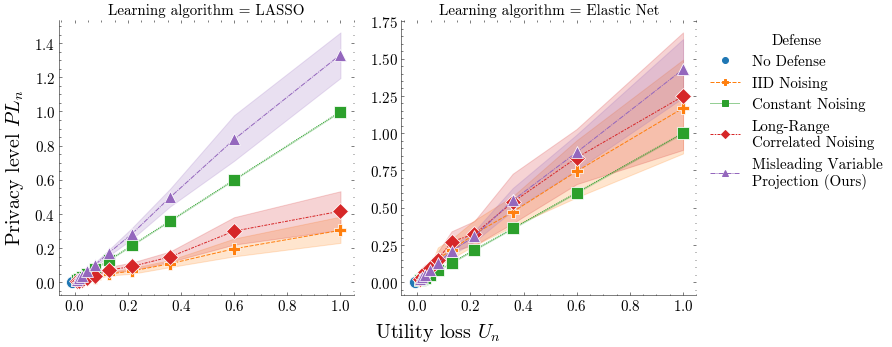

In [83]:
g = sns.relplot(
    data=df, x="un", y="error", style='defense', markers=markers, legend=True, palette=palette, markersize=12,
    hue="defense", kind='line', facet_kws={'sharey': False, 'sharex': True}, col='attack'
) 
# plt.xscale('log')
# plt.yscale('log')
for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
g.fig.supxlabel(r'Utility loss $U_n$')
g.fig.supylabel(r'Privacy level $PL_n$')
g.set_titles(template='')

for ax,m in zip(g.axes[0,:],df['attack'].unique()):
    ax.set_title(f'Learning algorithm = {m}')
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    
handles, labels = g.axes.ravel()[0].get_legend_handles_labels()
g.legend.set_visible(False)
handles[0].set_linestyle("")
new_handles = handles
new_labels = labels
leg = plt.legend(new_handles, new_labels, title='Defense', bbox_to_anchor=(1, 1))
# new_handles = [plt.plot([],marker="", ls="")[0]]+handles
# new_labels = [r'$\bf{Defense:}$']+labels

# leg = plt.legend(new_handles, new_labels, title='', bbox_to_anchor=(-0.4, 1.35), ncol=3)
# leg._legend_box.align = "left"
# leg.get_title().set_position((-2.8, 2.4))
# plt.tight_layout()
# plt.savefig(f'./plots/lasso_sim_{kind}_acc.pdf')

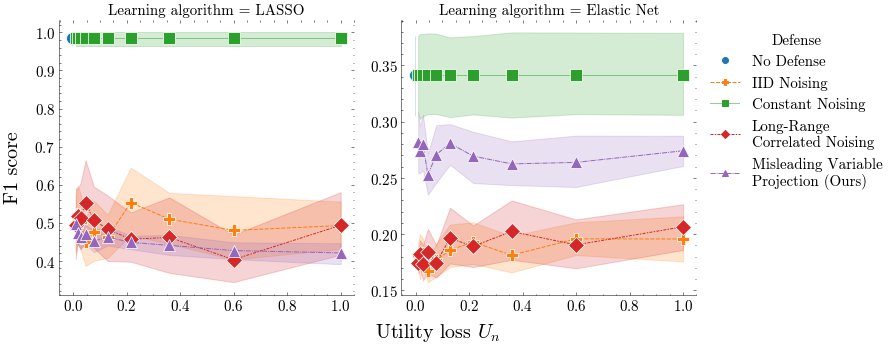

In [64]:
g = sns.relplot(
    data=df, x="un", y="f1", style='defense', markers=markers, legend=True, palette=palette, markersize=12,
    hue="defense", kind='line', facet_kws={'sharey': False, 'sharex': True}, col='attack'
) 
for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
g.fig.supxlabel(r'Utility loss $U_n$')
g.fig.supylabel('F1 score')
g.set_titles(template='')

for ax,m in zip(g.axes[0,:],df['attack'].unique()):
    ax.set_title(f'Learning algorithm = {m}')
    
handles, labels = g.axes.ravel()[0].get_legend_handles_labels()
g.legend.set_visible(False)
handles[0].set_linestyle("")
new_handles = handles
new_labels = labels
leg = plt.legend(new_handles, new_labels, title='Defense', bbox_to_anchor=(1, 1))
# new_handles = [plt.plot([],marker="", ls="")[0]]+handles
# new_labels = [r'$\bf{Defense:}$']+labels

# leg = plt.legend(new_handles, new_labels, title='', bbox_to_anchor=(-0.5, 1.35), ncol=3)
# leg._legend_box.align = "left"
# leg.get_title().set_position((-2.8, 2.4))
# plt.tight_layout()
plt.savefig(f'./plots/lasso_sim_{kind}_f1.pdf')

In [66]:
for kind in range(1,8):
    df = pd.read_csv(f'./saved_models/lasso_sim_{kind}.csv', index_col=0)
    df = df[df['attack'] != 'Ridge']
    g = sns.relplot(
    data=df, x="un", y="sym_diff", style='defense', markers=markers, legend=True, palette=palette, markersize=12,
    hue="defense", kind='line', facet_kws={'sharey': False, 'sharex': True}, col='attack'
    ) 
    for ax in g.axes.flatten():
        ax.set_xlabel('')
        ax.set_ylabel('')
    g.fig.supxlabel(r'Utility loss $U_n$')
    g.fig.supylabel('Symmetric Difference')
    g.set_titles(template='')

    for ax,m in zip(g.axes[0,:],df['attack'].unique()):
        ax.set_title(f'Learning algorithm = {m}')

    handles, labels = g.axes.ravel()[0].get_legend_handles_labels()
    g.legend.set_visible(False)
    handles[0].set_linestyle("")
    new_handles = handles
    new_labels = labels
    leg = plt.legend(new_handles, new_labels, title='Defense', bbox_to_anchor=(1, 1))
    # new_handles = [plt.plot([],marker="", ls="")[0]]+handles
    # new_labels = [r'$\bf{Defense:}$']+labels

    # leg = plt.legend(new_handles, new_labels, title='', bbox_to_anchor=(-0.5, 1.35), ncol=3)
    # leg._legend_box.align = "left"
    # leg.get_title().set_position((-2.8, 2.4))
    # plt.tight_layout()
    plt.savefig(f'./plots/lasso_sim_{kind}_diff.pdf')
    plt.close()

In [32]:
from sklearn.metrics.pairwise import PAIRWISE_KERNEL_FUNCTIONS, KERNEL_PARAMS


def empirical_ntk_jacobian_contraction(fnet_single, params, x1, x2):
    # Compute J(x1)
    jac1 = vmap(jacrev(fnet_single), (None, 0))(params, x1)
    jac1 = [j.flatten(2) for j in jac1]
    
    # Compute J(x2)
    jac2 = vmap(jacrev(fnet_single), (None, 0))(params, x2)
    jac2 = [j.flatten(2) for j in jac2]
    
    # Compute J(x1) @ J(x2).T
    result = torch.stack([torch.einsum('Naf,Mbf->NMab', j1, j2) for j1, j2 in zip(jac1, jac2)])
    result = result.sum(0)
    return result


def ntk_kernel(x,y, fnet_single=None, params=None):
    x = torch.from_numpy(x).to(torch.float)
    y = torch.from_numpy(y).to(torch.float)
    res = empirical_ntk_jacobian_contraction(fnet_single, params, x, y).squeeze()
    return res.detach().numpy()

KERNEL_PARAMS['ntk'] = ('fnet_single', 'params')
PAIRWISE_KERNEL_FUNCTIONS['ntk'] = ntk_kernel

In [12]:
device = 'cpu'
dims = [1, 1000, 1]

In [26]:
# krr.update(dict(alpha=1e-3, kernel='ntk', emp=1000, 
#                 kernel_params=dict(fnet_single=fnet_single2, params=params2)))

X_valid = np.random.uniform(0,1,size=2000)
valid_data = SimData(X_valid.reshape(-1,1), f(X_valid))
emp_data = valid_data.X[np.random.choice(len(valid_data), 1000), :]

krr = dict(defend_method='NTKReg', sigma=sigma, device=device, emp_data=emp_data, alpha=1e-3)
defense_dict['KRR'] = krr

In [51]:
fnet, params = make_functional(FC(*dims)) # FC(*dims)  teacher
fnet_single = lambda params, x: fnet(params, x.unsqueeze(0)).squeeze(0)
# alg_dict = dict(learning_algorithm='KRR', 
#                 alg_kwargs=dict(alpha=1e-3, kernel='ntk', 
#                                 kernel_params=dict(fnet_single=fnet_single, params=params)))

# fnet2, params2 = make_functional(teacher)
# fnet_single2 = lambda params, x: fnet2(params, x.unsqueeze(0)).squeeze(0)

krr = dict(defend_method='KRR', sigma=sigma)
krr.update(dict(query_strategy='IID', query_kwargs=dict(interval=[0, 1], type='unif')))
krr.update(dict(alpha=1e-3, kernel='ntk', emp=1000, 
                kernel_params=dict(fnet_single=fnet_single, params=params)))
defense_dict['KRR'] = krr

In [68]:
    krr = dict(defend_method='KRR', sigma=sigma)
    krr.update(dict(query_strategy='IID', query_kwargs=dict(interval=[0, 1], type='unif')))
    krr.update(dict(alpha=1e-2, kernel='rbf', kernel_params=dict()))
    defense_dict['KRR'] = krr

### KRR NTK defense + KRR NTK attack + unif query 

In [69]:
%%time
n_train = 100

krr = dict(defend_method='KRR', sigma=sigma)
krr.update(dict(query_strategy='IID', query_kwargs=dict(interval=[0, 1], type='unif')))
krr.update(dict(alpha=1e-3, kernel='ntk', emp=1000, 
                kernel_params=dict(fnet_single=fnet_single, params=params)))
defense_dict['KRR'] = krr
alg_dict = dict(learning_algorithm='KRR', 
            alg_kwargs=dict(alpha=1e-3, kernel='ntk', 
                            kernel_params=dict(fnet_single=fnet_single, params=params)))
query_dict = dict(query_strategy='IID', query_kwargs=dict(interval=[0, 1], type='unif'))
#     query_dict = dict(query_strategy='IID', query_kwargs=dict(interval=[0, 1], type='Beta', alpha=1, beta=3))

for defense in defense_dict:
    n_rep = 10
    test_error = np.zeros(n_rep)
    an = np.zeros(n_rep)
    # Initialize the defender and attacker
    server = Server(model=f, **defense_dict[defense])
    attacker = Attacker(**query_dict, **alg_dict)
    for i in range(n_rep):
        test_error[i] = exp(server, attacker, n_train, valid)
        an[i] = sigma**2

    print(defense, np.mean(test_error), np.std(test_error))

None 1.8711152105073516e-05 1.813452972140359e-05
IID 0.0756340605908554 0.012091553848356883
Const 0.25034823353464114 0.00037580147975560497
Corr 0.07455641247584291 0.015245105125986924
KRR 0.05735571050779078 0.008922123583506006
LR 0.28627552644726434 0.071296504120885
CPU times: user 59.8 s, sys: 1min 17s, total: 2min 17s
Wall time: 8.98 s


### KRR NTK defense + LeNet attack + unif query

In [74]:
%%time
n_train = 100

krr = dict(defend_method='KRR', sigma=sigma)
krr.update(dict(query_strategy='IID', query_kwargs=dict(interval=[0, 1], type='unif')))
krr.update(dict(alpha=1e-3, kernel='ntk', emp=1000, 
                kernel_params=dict(fnet_single=fnet_single, params=params)))
defense_dict['KRR'] = krr
alg_dict = dict(learning_algorithm='LeNet5',
                        alg_kwargs=dict(model=FCNTK(*dims),
                                        device=device, train_loss=nn.MSELoss(),
                                        batch_size=64, num_epochs=100,
                                        scheduler=None))
query_dict = dict(query_strategy='IID', query_kwargs=dict(interval=[0, 1], type='unif'))

for defense in defense_dict:
    n_rep = 10
    test_error = np.zeros(n_rep)
    an = np.zeros(n_rep)
    # Initialize the defender and attacker
    server = Server(model=f, **defense_dict[defense])
    attacker = Attacker(**query_dict, **alg_dict)
    for i in range(n_rep):
        test_error[i] = exp(server, attacker, n_train, valid)
        an[i] = sigma**2

    print(defense, np.mean(test_error), np.std(test_error))

None 0.004719395753087471 0.008642046682944047
IID 0.006084638433241533 0.00304313399679468
Const 0.25000142457421204 0.0040521284789723985
Corr 0.011887385471016912 0.007329199421873463
KRR 0.0006333772062237318 0.0002629873757083057
LR 0.23753413656013192 0.04917847931878136
CPU times: user 1min 44s, sys: 42.5 s, total: 2min 26s
Wall time: 14.6 s


In [78]:
defense = 'KRR'
server = Server(model=f, **defense_dict[defense])
attacker = Attacker(**query_dict, **alg_dict)
attacker.collect_data(n_train, server)
x, y = attacker.data

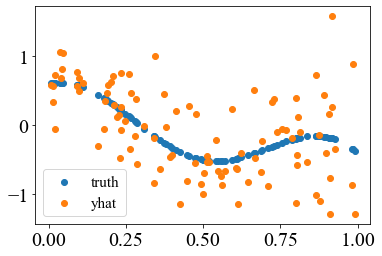

In [89]:
plt.scatter(x, f(x), label='truth')
plt.scatter(x, y, label='yhat')
plt.legend()

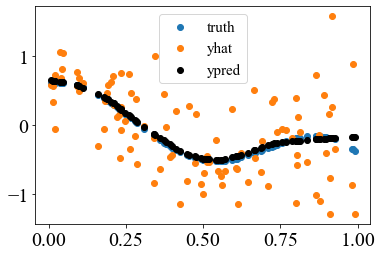

In [88]:
attacker.data = (x, y)
attacker.train()
ypred = attacker.algorithm.predict(x)
plt.scatter(x, f(x), label='truth')
plt.scatter(x, y, label='yhat')
plt.scatter(x, ypred, label='ypred', color='black')
plt.legend()

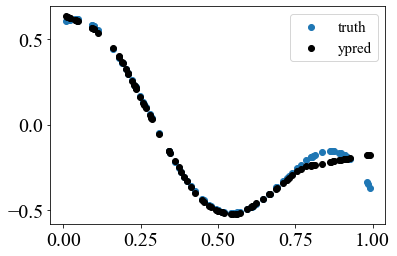

In [87]:
attacker.data = (x, f(x))
attacker.train()
ypred = attacker.algorithm.predict(x)
plt.scatter(x, f(x), label='truth')
plt.scatter(x, ypred, label='ypred', color='black')
plt.legend()

### KRR defense + KRR NTK attack + unif query

In [71]:
%%time
n_train = 100

krr = dict(defend_method='KRR', sigma=sigma)
krr.update(dict(query_strategy='IID', query_kwargs=dict(interval=[0, 1], type='unif')))
krr.update(dict(alpha=1e-3, kernel='rbf', kernel_params=dict()))
defense_dict['KRR'] = krr
alg_dict = dict(learning_algorithm='KRR', 
            alg_kwargs=dict(alpha=1e-2, kernel='ntk', 
                            kernel_params=dict(fnet_single=fnet_single, params=params)))
query_dict = dict(query_strategy='IID', query_kwargs=dict(interval=[0, 1], type='unif'))

for defense in defense_dict:
    n_rep = 10
    test_error = np.zeros(n_rep)
    an = np.zeros(n_rep)
    # Initialize the defender and attacker
    server = Server(model=f, **defense_dict[defense])
    attacker = Attacker(**query_dict, **alg_dict)
    for i in range(n_rep):
        test_error[i] = exp(server, attacker, n_train, valid)
        an[i] = sigma**2

    print(defense, np.mean(test_error), np.std(test_error))

None 3.568606360636789e-05 1.499330407040391e-05
IID 0.029869459118461828 0.008401372283421553
Const 0.2503218557717845 0.0005837122992189286
Corr 0.03540356345574659 0.012093362314804602
KRR 0.3152717359994568 0.07124602976133701
LR 0.25418355611973753 0.048055567697611525
CPU times: user 49 s, sys: 52.8 s, total: 1min 41s
Wall time: 6.93 s


### KRR defense + NN attack + unif query

In [60]:
defense_dict['LR'] = dict(defend_method='LR', sigma=sigma, p=3)

In [72]:
%%time
n_train = 100

krr = dict(defend_method='KRR', sigma=sigma)
krr.update(dict(query_strategy='IID', query_kwargs=dict(interval=[0, 1], type='unif')))
krr.update(dict(alpha=1e-3, kernel='rbf', kernel_params=dict()))
defense_dict['KRR'] = krr
alg_dict = dict(learning_algorithm='LeNet5',
                        alg_kwargs=dict(model=FCNTK(*dims),
                                        device=device, train_loss=nn.MSELoss(),
                                        batch_size=64, num_epochs=100,
                                        scheduler=None))
query_dict = dict(query_strategy='IID', query_kwargs=dict(interval=[0, 1], type='unif'))

for defense in defense_dict:
    n_rep = 10
    test_error = np.zeros(n_rep)
    an = np.zeros(n_rep)
    # Initialize the defender and attacker
    server = Server(model=f, **defense_dict[defense])
    attacker = Attacker(**query_dict, **alg_dict)
    for i in range(n_rep):
        test_error[i] = exp(server, attacker, n_train, valid)
        an[i] = sigma**2

    print(defense, np.mean(test_error), np.std(test_error))

None 0.0026945265745327222 0.004071170372272726
IID 0.00744775261172183 0.006327290164322735
Const 0.25132702257161155 0.002138506385751068
Corr 0.024460256869061114 0.012512930643353693
KRR 0.2927177115865385 0.03837970961946018
LR 0.24540283411338434 0.07351771921598509
CPU times: user 1min 33s, sys: 11.3 s, total: 1min 44s
Wall time: 11.9 s
